#**Análisis de las lluvias en Australia**

##**1. Presentación de dataset**

Este data set presenta datos 10 años de observaciones climáticas de muchas locaciones en Australia.
El análisis de este dataset fue realizado con el propósito de predecir si el día siguiente lloverá o no en lus lugares de estudio dentro de Australia.


###**1.1. Objetivo del análisis**

El análisis de este objetivo es crear un modelo predictivo que permita saber si lloverá al día siguiente.

###**1.2. Desafio del dataset**

 Datos faltantes en varias variables numéricas:

1) Posible estacionalidad

2) Diferencias entre ubicaciones geográficas

3) Tamaño grande (el remuestreo del modelo puede ser más lento)

##**2. Descripción de las columnas del dataset**



El dataset contiene las siguientes columnas:

- **Date** — Fecha de la observación.
- **Location** — Ciudad o estación meteorológica.
- **MinTemp** — Temperatura mínima del día (°C).
- **MaxTemp** — Temperatura máxima del día (°C).
- **Rainfall** — Cantidad de lluvia (mm).
- **Evaporation** — Evaporación medida (mm).
- **Sunshine** — Horas de sol.
- **WindGustDir** — Dirección de la ráfaga de viento más fuerte.
- **WindGustSpeed** — Velocidad de la ráfaga más fuerte (km/h).
- **WindDir9am** — Dirección del viento a las 9am.
- **WindDir3pm** — Dirección del viento a las 3pm.
- **WindSpeed9am** — Velocidad del viento a las 9am (km/h).
- **WindSpeed3pm** — Velocidad del viento a las 3pm (km/h).
- **Humidity9am** — Humedad relativa a las 9am (%).
- **Humidity3pm** — Humedad relativa a las 3pm (%).
- **Pressure9am** — Presión atmosférica a las 9am (hPa).
- **Pressure3pm** — Presión atmosférica a las 3pm (hPa).
- **Cloud9am** — Cobertura de nubes a las 9am (octas).
- **Cloud3pm** — Cobertura de nubes a las 3pm (octas).
- **Temp9am** — Temperatura a las 9am (°C).
- **Temp3pm** — Temperatura a las 3pm (°C).
- **RainToday** — Si llovió hoy (Yes/No).
- **RainTomorrow** — Variable objetivo: si lloverá mañana (Yes/No).

##**3. Librerias de trabajo**

In [13]:
# Manipulación de datos
import numpy as np
import pandas as pd
import os
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística e inferencia
from scipy import stats
from scipy.stats import shapiro, normaltest, mode

#Conexión con Googledrive
#from google.colab import drive

# Configuración de visualización
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Opciones de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

#Registrar operaciones
import logging
import chardet

# Semilla para reproducibilidad
np.random.seed(42)

#print("Bibliotecas importadas exitosamente")

# Configuración de visualización y advertencias
pd.set_option('display.max_columns', None) # Para asegurar que se vean todas las columnas al imprimir
import warnings
warnings.filterwarnings('ignore') # Limpiar la salida de advertencias rojas

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Notebook iniciado correctamente.")

2026-06-27 18:23:19,212 - INFO - Notebook iniciado correctamente.


##**4. Cargar ruta de archivo**

Se cargó el dataset de Lluvias en Australia.

In [14]:
# Conectar Google Drive
#drive.mount('/content/drive')
# Acceder al directorio donde está el archivo
#ruta = '/content/drive/MyDrive/magister/Estadisticas_computacionales'
#os.chdir(ruta)

##**5. Presentación de dataset**


Para la presentación de datos se requiere revisar los siguientes puntos:

* Primeras 10 filas
* Últimas 10 filas
* Codificación del dataset
* Tipo de datos
* num de filas y columnas
* Duplicados
* Nombre de las columnas
* Valores atípicos o inconsistentes
* Min/Max
* Valores faltantes




###**5.1 Primeras 10 filas**

In [15]:
#Primeras 10 filas del dataset y registro de carga de datos
#file_path = os.path.join(ruta, 'weatherAUS.csv')
#df = pd.read_csv(file_path)
#display(df.head(10))

file_path = 'Dataset/Raw/weatherAUS.csv'  # Cambia la ruta si es necesario

try:
    df = pd.read_csv(file_path)
    logging.info("Archivo weatherAUS.csv leído correctamente.")
    display(df.head(10))
except FileNotFoundError:
    logging.error("El archivo no fue encontrado. Verifica la ruta.")
except pd.errors.ParserError:
    logging.error("Error al parsear el CSV. Revisa el formato o separador.")
except Exception as e:
    logging.error(f"Ocurrió un error inesperado: {e}")

2026-06-27 18:23:19,222 - INFO - Archivo encontrado en: c:\Users\UsuarioCompuElite\Documents\Estad-stica-computacional-Grupo-9-\Dataset\Raw\weatherAUS.csv
2026-06-27 18:23:19,413 - INFO - Archivo weatherAUS.csv leído correctamente.
2026-06-27 18:23:19,413 - INFO - Archivo weatherAUS.csv leído correctamente.


2026-06-27 18:23:19,222 - INFO - Archivo encontrado en: c:\Users\UsuarioCompuElite\Documents\Estad-stica-computacional-Grupo-9-\Dataset\Raw\weatherAUS.csv
2026-06-27 18:23:19,413 - INFO - Archivo weatherAUS.csv leído correctamente.
2026-06-27 18:23:19,413 - INFO - Archivo weatherAUS.csv leído correctamente.


✅ Dataset cargado exitosamente
Dimensiones: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,W,19.0,24.0,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,W,20.0,24.0,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,W,6.0,17.0,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,NW,7.0,28.0,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,SSE,15.0,11.0,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


###**5.2 Codificación del dataset**

Se presentó la codificación del dataset

In [16]:
# Lee el archivo para conocer la códificación del archivo
file_path = os.path.join('..', '..', 'Dataset', 'Raw', 'weatherAUS.csv')

try:
    with open(file_path, 'rb') as f:
        datos = f.read(10000)  # Lee los 10000 primeros bytes del archivo

    # Codificación
    det_cod = chardet.detect(datos)
    cod = det_cod['encoding']

    print(f"Codificación detectada: {cod}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en {os.path.abspath(file_path)}")
except Exception as e:
    print(f"Error al leer el archivo: {e}")


Codificación detectada: ascii


###**5.3 Información general del dataset**

Se presentaron las columnas, conteo de no nulos  y tipo de variables

In [17]:
#Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


El número total de datos consta de 145460, correspondiente a las columnas de Date y Location. El resto de las columnas presentan menos datos que las mencionadas anteriormente. La columna Date se muestra de tipo Object. Esta debe transformar en datetime64[ns].

###**5.4 Ultimas 10 filas**

In [18]:
# 10 últimos registros
df.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,13.0,7.0,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,2017-06-25,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,ESE,17.0,17.0,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


###**5.5 Número de filas y columnas**

In [19]:
#Filas y columnas del dataset
df.shape

(145460, 23)

###**5.6 Estadistica descriptiva inicial**

In [20]:
#Estadistica descriptiva inicial
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000,144199.000,142199.000,82670.000,75625.000,135197.000,143693.000,142398.000,142806.000,140953.000,130395.000,130432.000,89572.000,86102.00,143693.000,141851.000
mean,12.194,23.221,2.361,5.468,7.611,40.035,14.043,18.663,68.881,51.539,1017.650,1015.256,4.447,4.51,16.991,21.683
std,6.398,7.119,8.478,4.194,3.785,13.607,8.915,8.810,19.029,20.796,7.107,7.037,2.887,2.72,6.489,6.937
min,-8.500,-4.800,0.000,0.000,0.000,6.000,0.000,0.000,0.000,0.000,980.500,977.100,0.000,0.00,-7.200,-5.400
25%,7.600,17.900,0.000,2.600,4.800,31.000,7.000,13.000,57.000,37.000,1012.900,1010.400,1.000,2.00,12.300,16.600
50%,12.000,22.600,0.000,4.800,8.400,39.000,13.000,19.000,70.000,52.000,1017.600,1015.200,5.000,5.00,16.700,21.100
75%,16.900,28.200,0.800,7.400,10.600,48.000,19.000,24.000,83.000,66.000,1022.400,1020.000,7.000,7.00,21.600,26.400
max,33.900,48.100,371.000,145.000,14.500,135.000,130.000,87.000,100.000,100.000,1041.000,1039.600,9.000,9.00,40.200,46.700


###**5.7 Muestreo aleatorio**

In [21]:
#Muestreo aleatorio del dataset
df.sample(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
100721,2012-04-22,MountGambier,15.0,18.9,4.2,6.6,8.0,NNW,54.0,NNW,NW,24.0,31.0,73.0,64.0,1005.2,1003.7,4.0,5.0,17.3,17.6,Yes,Yes
30234,2008-03-30,Sydney,13.1,26.8,0.0,4.6,10.9,NaN,NaN,W,WNW,22.0,15.0,61.0,22.0,1013.0,1009.0,0.0,1.0,16.9,25.9,No,No
68427,2011-12-10,Melbourne,19.0,29.0,NaN,11.0,5.6,N,59.0,N,N,39.0,22.0,50.0,38.0,1006.5,1003.4,NaN,NaN,24.2,27.2,NaN,NaN
28624,2013-03-27,Richmond,18.1,32.2,0.0,2.1,NaN,NE,30.0,NaN,NE,0.0,17.0,99.0,51.0,1019.2,1014.6,NaN,NaN,20.9,31.6,No,No
31173,2010-10-25,Sydney,13.9,19.6,14.0,1.2,5.4,SSW,50.0,SW,S,17.0,22.0,90.0,64.0,NaN,1018.4,7.0,6.0,15.5,19.1,Yes,No


###**5.8 Nombre de las columnas**

In [22]:
#Nombre de las columnas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')

###**5.9 Tipo de datos**

In [23]:
#Tipo de datos
df.dtypes

Date                 str
Location             str
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir          str
WindGustSpeed    float64
WindDir9am           str
WindDir3pm           str
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday            str
RainTomorrow         str
dtype: object

================================================================================================================================================================================================================================================================================================================

##**6. Exploración de datos**

###**6.1.  Número de datos faltantes por columna**

1) Se creo una matriz de datos faltantes que contienen los nulos del dataset.

2) Se verificó si existia al menos un dato faltante por columna

3) Se contó el número de datos faltantes por columna

4) Se contó el número de datos faltantes total del dataset


In [24]:
# Ver matriz booleana de datos faltantes
print('\nDatos faltantes\n')
faltantes_matrix = df.isnull()
print(faltantes_matrix.head())
# Verificar si hay al menos un dato faltante por columna
print('\nVerifica si al menos existe un dato faltantes por columna\n')
print(df.isnull().any())
# Contar el número de datos faltantes por columna
print('\nNúmero de datos faltantes por columna\n')
print(df.isnull().sum())
#Contar el número de datos faltantes totales
print('\nNúmero de datos faltantes totales\n')
print(df.isnull().sum().sum())


Datos faltantes

    Date  Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  False     False    False    False     False         True      True   
1  False     False    False    False     False         True      True   
2  False     False    False    False     False         True      True   
3  False     False    False    False     False         True      True   
4  False     False    False    False     False         True      True   

   WindGustDir  WindGustSpeed  WindDir9am  WindDir3pm  WindSpeed9am  \
0        False          False       False       False         False   
1        False          False       False       False         False   
2        False          False       False       False         False   
3        False          False       False       False         False   
4        False          False       False       False         False   

   WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  \
0         False        False       

###**6.2 Número de nulos por columnas de mayor a menor**

Se ordenaron las columnas según el número de datos faltantes por columna y de mayor a menor

In [25]:
#Nulos por columna ordenado de mayor a menor
nulos_por_columna = df.isnull().sum()
nulos_ordenados = nulos_por_columna.sort_values(ascending=False)
print("\nColumnas ordenadas por cantidad de nulos (de mayor a menor):\n")
print(nulos_ordenados)


Columnas ordenadas por cantidad de nulos (de mayor a menor):

Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
WindSpeed3pm      3062
Humidity9am       2654
WindSpeed9am      1767
Temp9am           1767
MinTemp           1485
MaxTemp           1261
Date                 0
Location             0
dtype: int64


###**6.3 Número de nulos por fila**

Se calcularon la cantidad de nulos por filas y total

In [26]:
#Número de nulos por fila
nulos_por_fila = df.isnull().sum(axis=1)#fila
print("\nCantidad de nulos por fila:\n")
print(nulos_por_fila)

#Número de nulos por fila totales
nulos_totales_filas = df.isnull().sum(axis=1).sum()
print("\nCantidad total de nulos por fila:\n")
print(nulos_totales_filas)



Cantidad de nulos por fila:

0         3
1         4
2         3
3         4
4         2
         ..
145455    4
145456    4
145457    4
145458    2
145459    6
Length: 145460, dtype: int64

Cantidad total de nulos por fila:

343248


###**6.4 % nulos por columnas**

In [27]:
#porcentaje de nulos en el dataset
porcentaje_nulos = df.isnull().mean() * 100
print(porcentaje_nulos)

Date              0.000
Location          0.000
MinTemp           1.021
MaxTemp           0.867
Rainfall          2.242
Evaporation      43.167
Sunshine         48.010
WindGustDir       7.099
WindGustSpeed     7.056
WindDir9am        7.264
WindDir3pm        2.907
WindSpeed9am      1.215
WindSpeed3pm      2.105
Humidity9am       1.825
Humidity3pm       3.098
Pressure9am      10.357
Pressure3pm      10.331
Cloud9am         38.422
Cloud3pm         40.807
Temp9am           1.215
Temp3pm           2.481
RainToday         2.242
RainTomorrow      2.246
dtype: float64



###**6.5 % total de nulos**

In [28]:
#porcentaje total de nulos en el dataset
total_nulos = df.isnull().sum().sum()
total_celdas = df.size
porcentaje_total_nulos = (total_nulos / total_celdas) * 100
print(f"El porcentaje total de valores nulos en el dataset es: {porcentaje_total_nulos:.2f}%")

El porcentaje total de valores nulos en el dataset es: 10.26%



Ya que existen mas del 10% de datos totales faltantes, se deben revisar los métodos de imputación para la información. En un diagnóstico inicial es probable que existan columnas con outliers que esten deformando la estadística de los datos.

###**6.6 Número de filas duplicadas**

In [29]:
# Detectar filas duplicadas
dups = df.duplicated()
print("Filas duplicadas:\n", dups.value_counts())
#conteo de True/False

Filas duplicadas:
 False    145460
Name: count, dtype: int64


No existen filas duplicadas para el dataset

##**7. Aplicación de estadística descriptiva**

Este notebook realizó lo siguiente:
- Conversión de tipos de datos (Convertir fecha)
- Cálculo de media, mediana y moda (SciPy)(sin considerar los valores faltantes)
- Selección automática del método adecuado usando la **regla del 20%**
- Funciones separadas para columnas numéricas y categóricas
- Justificación basada en los resultados reales
- Imputación de valores faltantes
- Logging detallado


###**7.1 Conversión de tipos de datos**

Se convirtio la columna Date del dataset de object a datetime64.

In [30]:
try:
    # Memoria antes de la optimización
    mem_antes = df.memory_usage(deep=True).sum()

    # Conversión de fecha
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # Columnas categóricas
    categoricas_cols = [
        'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
        'RainToday', 'RainTomorrow'
    ]
    for col in categoricas_cols:
        df[col] = df[col].astype('category')

    # Columnas numéricas (float)
    numerica_cols = [
        'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
        'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
        'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
        'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'
    ]
    for col in numerica_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Memoria después de la optimización
    mem_despues = df.memory_usage(deep=True).sum()

    print(f"Memoria inicial:    {mem_antes:,} bytes")
    print(f"Memoria optimizada: {mem_despues:,} bytes")
    print(f"Reducción:          {(1 - mem_despues / mem_antes) * 100:.1f}%")
    print("Conversión de tipos completada.")

except Exception as e:
    print(f"Error durante la conversión de tipos: {e}")

Memoria inicial:    72,231,001 bytes
Memoria optimizada: 20,660,943 bytes
Reducción:          71.4%
Conversión de tipos completada.


In [31]:
#Verificación de la conversión de la columna Date
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[us]
 1   Location       145460 non-null  category      
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  category      
 8   WindGustSpeed  135197 non-null  float64       
 9   WindDir9am     134894 non-null  category      
 10  WindDir3pm     141232 non-null  category      
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 non-null  float64       
 14  Humidity3pm    140953 non-null  float64       
 15  Pressure9am

Se puede observar en la columna 0 que la columna ha cambiado de tipo de datos.

###**7.2 Cálculo de media, mediana y moda (sin considerar los valores faltantes)**

#### **7.2.1 Estrategias de Imputación de Valores Faltantes**

Para decidir la mejor estrategia de imputación, es crucial considerar el porcentaje de valores nulos y el tipo de dato de cada columna, con el objetivo de minimizar la alteración de la distribución estadística del dataset.

1.  **Variables Numéricas con bajo/moderado porcentaje de nulos (ej. < 10-15% como `MinTemp`, `MaxTemp`, `Rainfall`, `WindSpeed9am`, `Temp9am`, `Temp3pm`, `Humidity9am`, `Humidity3pm`, `WindSpeed3pm`):**
    *   **Imputación por Mediana:** Es robusta a los valores atípicos y suele ser una buena opción cuando la distribución de los datos no es simétrica o contiene outliers. Preserva mejor la forma de la distribución que la media.
    *   **Imputación por Media:** Adecuada si la distribución de la variable es aproximadamente normal y no hay muchos valores atípicos. Sin embargo, puede sesgar la distribución si hay outliers.
    
2.  **Variables Categóricas con cualquier porcentaje de nulos (ej. `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`, `RainTomorrow`):**
    *   **Imputación por Moda:** Rellenar con el valor más frecuente es una estrategia común y simple para variables categóricas.
    *   **Crear una categoría 'Missing':** Si el hecho de que un valor sea nulo tiene un significado propio (ej. no hubo viento en una dirección específica), se puede crear una nueva categoría 'Missing' o 'Desconocido'. Esto preserva la información de la falta de datos.
    
3.  **Variables con alto porcentaje de nulos (ej. > 30-40% como `Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am`):**
    *   **Evaluación de la eliminación:** Si una columna tiene un porcentaje muy alto de nulos, imputarla con métodos simples (media/mediana/moda) podría distorsionar completamente su distribución y su relación con otras variables. Considera si la columna es crucial para tu análisis o modelo predictivo. Si no lo es, **eliminar la columna** podría ser la mejor opción para evitar introducir ruido.
    *   **Métodos Avanzados de Imputación:** Para estas columnas, si son críticas, se podrían considerar técnicas más sofisticadas como:
        *   **Imputación KNN (K-Nearest Neighbors):** Imputa los valores faltantes basándose en la similitud con las observaciones completas más cercanas. Es más robusta pero computacionalmente más intensiva.
        *   **Imputación MICE (Multiple Imputation by Chained Equations):** Genera múltiples conjuntos de datos imputados, lo que permite estimar la incertidumbre de la imputación. Es compleja de implementar pero muy potente.

###**7.3 Cálculo media, mediana y moda sin considerar los valores NaN**

Se calcularon las tendencias centrales del dataset para las columnas númericas 'df_numerico' sin considerar los valores faltantes.

In [32]:
print("\nCálculo de tendencias centrales y estrategia de imputación:\n")
#Seleccionar solo columnas numéricas (float)
df_numerica = df.select_dtypes(include=np.number)
for col in df_numerica.columns:
    serie       = df_numerica[col].dropna()
    media_nan   = np.nanmean(df_numerica[col])
    mediana_nan = np.nanmedian(df_numerica[col])
    moda_nan    = stats.mode(serie, keepdims=True).mode[0] if len(serie) > 0 else np.nan

    # Denominador: siempre positivo, prioriza mediana, fallback a media
    denom = abs(mediana_nan) if mediana_nan != 0 else abs(media_nan)

    if denom == 0:
        diff_abs, umbral, diff_pct = 0.0, 0.0, 0.0
    else:
        diff_abs  = abs(media_nan - mediana_nan)
        umbral = 0.20 * denom          # 20% del denominador positivo
        diff_pct  = diff_abs / denom * 100

    print(f"\nColumna '{col}':")
    print(f"  Media: {media_nan:.2f} | Mediana: {mediana_nan:.2f} | Moda: {moda_nan:.2f}")
    print(f"  Diferencia porcentual (|media - mediana| / |mediana|): {diff_pct:.1f}%")

    # Asimetría
    if abs(media_nan - mediana_nan) < 1e-9:
        print("  Media ≈ Mediana: Distribución aproximadamente simétrica.")
    elif media_nan > mediana_nan:
        print("  Media > Mediana: Asimetría positiva (cola derecha).")
    else:
        print("  Mediana > Media: Asimetría negativa (cola izquierda).")

    # Criterio y recomendación
    print(f"Criterio |x̄ − Me| > 0.20 × |Me|: {diff_abs:.2f} > {umbral:.2f} → {diff_abs > umbral}")

    if diff_pct > 20:
        print("ALERTA: Diferencia >20% — outliers probables.")
        print("Imputación recomendada: MEDIANA")
    else:
        print("Diferencia ≤20% — distribución aceptable.")
        print("Imputación recomendada: MEDIA")


Cálculo de tendencias centrales y estrategia de imputación:


Columna 'MinTemp':
  Media: 12.19 | Mediana: 12.00 | Moda: 11.00
  Diferencia porcentual (|media - mediana| / |mediana|): 1.6%
  Media > Mediana: Asimetría positiva (cola derecha).
Criterio |x̄ − Me| > 0.20 × |Me|: 0.19 > 2.40 → False
Diferencia ≤20% — distribución aceptable.
Imputación recomendada: MEDIA

Columna 'MaxTemp':
  Media: 23.22 | Mediana: 22.60 | Moda: 20.00
  Diferencia porcentual (|media - mediana| / |mediana|): 2.7%
  Media > Mediana: Asimetría positiva (cola derecha).
Criterio |x̄ − Me| > 0.20 × |Me|: 0.62 > 4.52 → False
Diferencia ≤20% — distribución aceptable.
Imputación recomendada: MEDIA

Columna 'Rainfall':
  Media: 2.36 | Mediana: 0.00 | Moda: 0.00
  Diferencia porcentual (|media - mediana| / |mediana|): 100.0%
  Media > Mediana: Asimetría positiva (cola derecha).
Criterio |x̄ − Me| > 0.20 × |Me|: 2.36 > 0.47 → True
ALERTA: Diferencia >20% — outliers probables.
Imputación recomendada: MEDIANA

Columna 

###**7.4 Moda para las columnas categoricas**

In [33]:
# Seleccionar solo columnas categóricas (object o category dtype)
df_categorico = df.select_dtypes(include=['object', 'category'])

print("\nModa para columnas categóricas:")
for col in df_categorico.columns:
    moda_serie = df_categorico[col].mode()

    if moda_serie.empty:
        print(f"  Columna '{col}': Sin moda (todos los valores son NaN)")
    elif len(moda_serie) == 1:
        freq_absoluta = df_categorico[col].value_counts().iloc[0]
        freq_relativa = freq_absoluta / df_categorico[col].notna().sum() * 100
        print(f"  Columna '{col}': Moda = '{moda_serie[0]}' "
              f"(frecuencia = {freq_absoluta}, {freq_relativa:.1f}%)")
    else:
        print(f"  Columna '{col}': Múltiples modas = {moda_serie.tolist()} "
              f"(distribución uniforme entre categorías)")


Moda para columnas categóricas:
  Columna 'Location': Moda = 'Canberra' (frecuencia = 3436, 2.4%)
  Columna 'WindGustDir': Moda = 'W' (frecuencia = 9915, 7.3%)
  Columna 'WindDir9am': Moda = 'N' (frecuencia = 11758, 8.7%)
  Columna 'WindDir3pm': Moda = 'SE' (frecuencia = 10838, 7.7%)
  Columna 'RainToday': Moda = 'No' (frecuencia = 110319, 77.6%)
  Columna 'RainTomorrow': Moda = 'No' (frecuencia = 110316, 77.6%)


###**Graficos de variables categoricas**

Barplot de la columna Location
Este gráfico muestra cuántos registros hay por cada ciudad.
Coincidiendo con el valor de moda "Canberra"

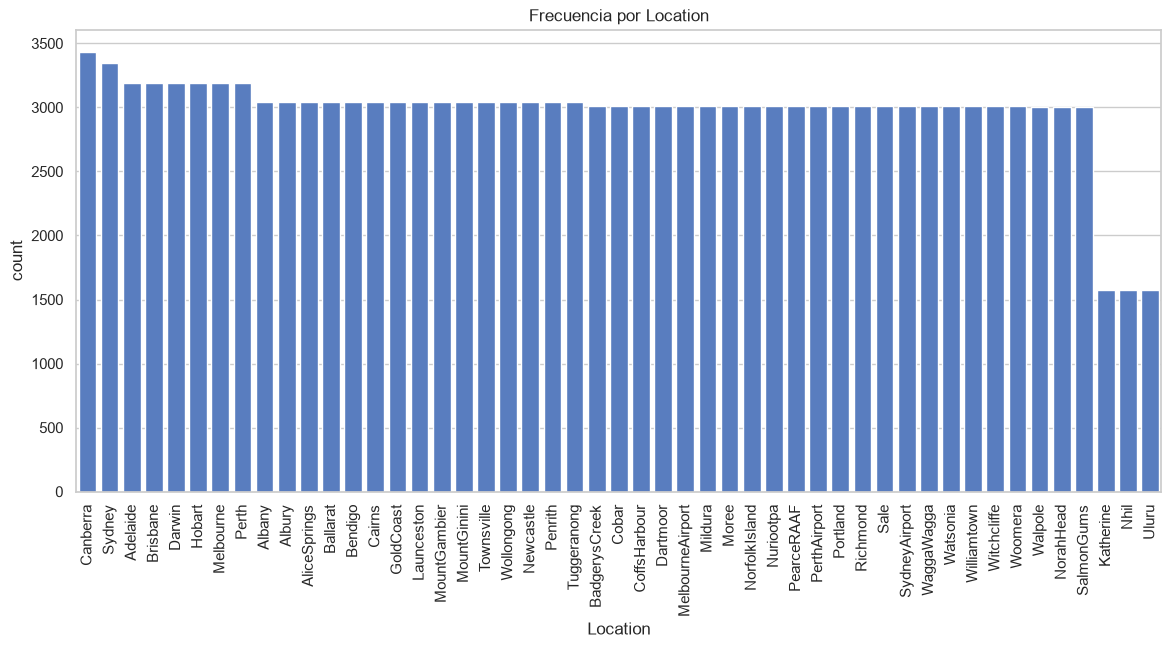

In [34]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x="Location", order=df["Location"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Frecuencia por Location")
plt.show()


Barplot de la columna RainToday
Este gráfico muestra cuántos días tienen lluvia registrada vs no.
Coincidiendo con el valor de moda "No"

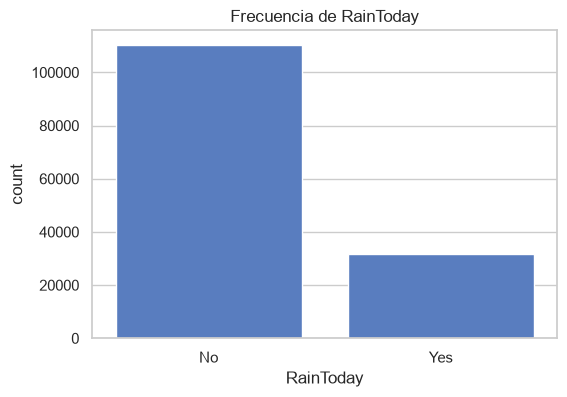

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="RainToday", order=df["RainToday"].value_counts().index)
plt.title("Frecuencia de RainToday")
plt.show()

Barplot combinado: RainToday por Location
Esto es útil para ver en qué ciudades llueve más.

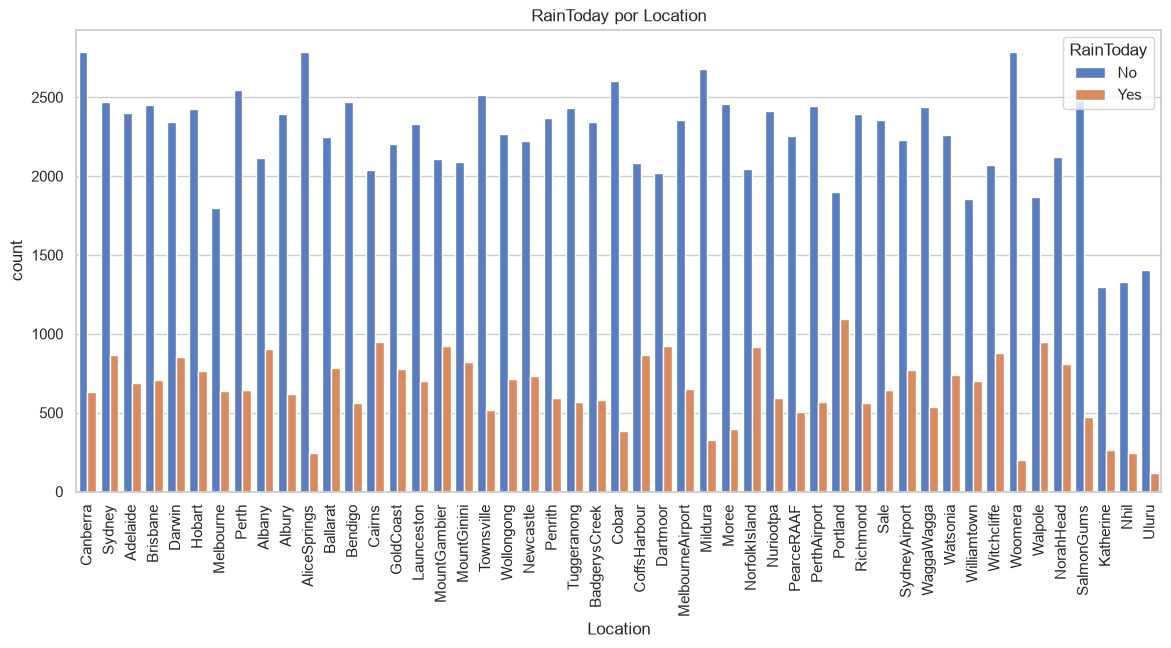

In [36]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x="Location", hue="RainToday",
              order=df["Location"].value_counts().index)
plt.xticks(rotation=90)
plt.title("RainToday por Location")
plt.show()

###**7.5 Cálculo de medidas de dispersión**

Se calcularon las medidas de dispersión para el dataset ignorando los valores faltantes.

In [37]:
# Medidas de dispersión por columna numérica
print("DISPERSIÓN:")
columnas_con_outliers = []

for col in df_numerica.columns:
    columnas_numericas = df_numerica[col]

    # Recalcula media ignorando NaN
    media_nan_col = np.nanmean(columnas_numericas)

    # Desviación estándar y varianza
    desv_std = columnas_numericas.std(ddof=1)
    varianza = columnas_numericas.var(ddof=1)

    # Coeficiente de variación
    if media_nan_col != 0:
        cv = (desv_std / media_nan_col) * 100
    else:
        cv = np.nan

    # Rango e IQR
    rango = columnas_numericas.max() - columnas_numericas.min()
    q1 = columnas_numericas.quantile(0.25)
    q3 = columnas_numericas.quantile(0.75)
    iqr = q3 - q1

    # Límites de Tukey para detectar outliers
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Detectar outliers
    outliers = columnas_numericas[
        (columnas_numericas < limite_inferior) | 
        (columnas_numericas > limite_superior)
    ]

    print(f"\nColumna '{col}':")
    print(f"   Desviación estándar: {desv_std:.2f}")
    print(f"   Varianza:            {varianza:.2f}")
    print(f"   Coef. de variación:  {cv:.2f}%")
    print(f"   Rango:               {rango:.2f}")
    print(f"   IQR:                 {iqr:.2f}")
    print(f"   Límite inferior:     {limite_inferior:.2f}")
    print(f"   Límite superior:     {limite_superior:.2f}")
    print(f"   Cantidad de outliers: {len(outliers)}")

    # Guardar columnas con outliers
    if len(outliers) > 0:
        columnas_con_outliers.append(col)

# Mostrar resumen final
print("\n📌 Columnas que contienen outliers según IQR:")
print(columnas_con_outliers)

DISPERSIÓN:

Columna 'MinTemp':
   Desviación estándar: 6.40
   Varianza:            40.94
   Coef. de variación:  52.47%
   Rango:               42.40
   IQR:                 9.30
   Límite inferior:     -6.35
   Límite superior:     30.85
   Cantidad de outliers: 54

Columna 'MaxTemp':
   Desviación estándar: 7.12
   Varianza:            50.68
   Coef. de variación:  30.66%
   Rango:               52.90
   IQR:                 10.30
   Límite inferior:     2.45
   Límite superior:     43.65
   Cantidad de outliers: 489

Columna 'Rainfall':
   Desviación estándar: 8.48
   Varianza:            71.88
   Coef. de variación:  359.10%
   Rango:               371.00
   IQR:                 0.80
   Límite inferior:     -1.20
   Límite superior:     2.00
   Cantidad de outliers: 25578

Columna 'Evaporation':
   Desviación estándar: 4.19
   Varianza:            17.59
   Coef. de variación:  76.69%
   Rango:               145.00
   IQR:                 4.80
   Límite inferior:     -4.60
   Lími

###**Graficos de Boxplot e Histograma para detectar outlier y colas largas**

Boxplot de la columna Railfall, que indica posibles outliers

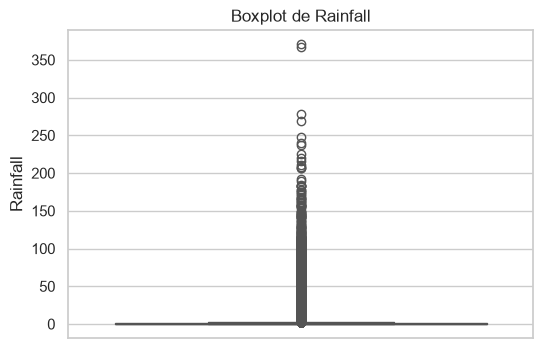

In [38]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_numerica, y="Rainfall")
plt.title("Boxplot de Rainfall")
plt.show()

Histograma de la columna Railfall

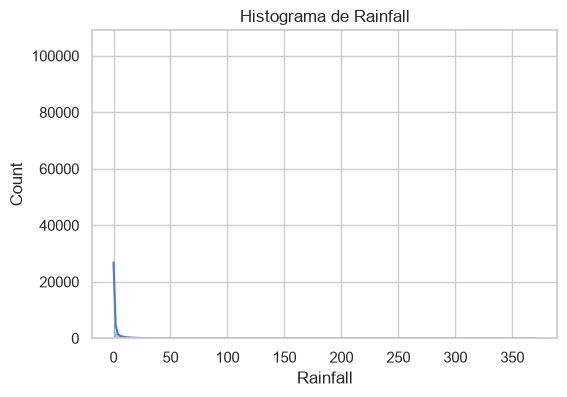

In [39]:
plt.figure(figsize=(6,4))
sns.histplot(df_numerica["Rainfall"], kde=True)
plt.title("Histograma de Rainfall")
plt.show()

Boxplot de la columna Humidity3pm, que indica posibles outliers

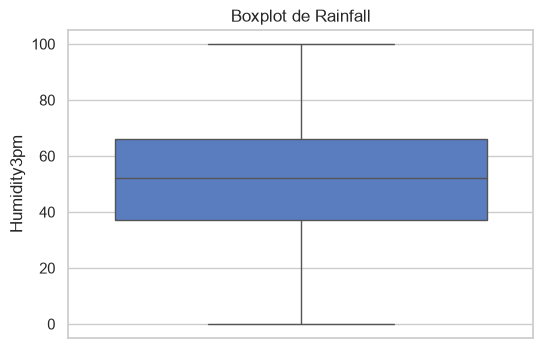

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_numerica, y="Humidity3pm")
plt.title("Boxplot de Rainfall")
plt.show()

Histograma de la columna Humidity3pm

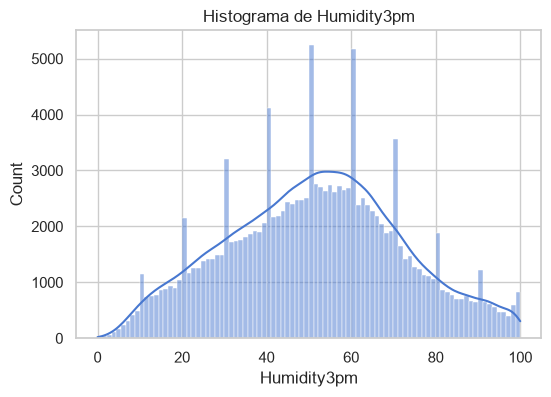

In [41]:
plt.figure(figsize=(6,4))
sns.histplot(df_numerica["Humidity3pm"], kde=True)
plt.title("Histograma de Humidity3pm")
plt.show()

Se determina que los calculos han sido los correctos con respecto a las formulas de las columnas que detectaron outliers

###**7.6 Cálculo de medidas de forma**

Se calcularon las medidas de forma de los datos

In [42]:
# Medidas de forma y cuartiles por columna numérica
print("FORMA DE LA DISTRIBUCIÓN Y CUARTILES:")
for col in df_numerica.columns:
    columnas_numericas_forma = df_numerica[col]

    if not columnas_numericas_forma.empty:
        asimetria = columnas_numericas_forma.skew()
        curtosis = columnas_numericas_forma.kurtosis()

        print(f"\nColumna '{col}':")
        print(f"   Asimetría (skewness):  {asimetria:.3f}")
        print(f"   Curtosis (kurtosis):   {curtosis:.3f}")

        # Interpretación de asimetría
        if abs(asimetria) < 0.5:
            print(f"   → Distribución aproximadamente simétrica")
        elif asimetria > 0:
            print(f"   → Asimetría positiva: cola hacia la derecha (valores altos)")
        else:
            print(f"   → Asimetría negativa: cola hacia la izquierda (valores bajos)")

        # Cuartiles y percentiles clave
        print("CUARTILES Y PERCENTILES:")
        print(f"   Mínimo:      {columnas_numericas_forma.min():.2f}")
        print(f"   Q1 (25%):    {columnas_numericas_forma.quantile(0.25):.2f}")
        print(f"   Q2 (50%):    {columnas_numericas_forma.quantile(0.50):.2f}")
        print(f"   Q3 (75%):    {columnas_numericas_forma.quantile(0.75):.2f}")
        print(f"   Máximo:      {columnas_numericas_forma.max():.2f}")
        print(f"   P90:         {columnas_numericas_forma.quantile(0.90):.2f}")
        print(f"   P95:         {columnas_numericas_forma.quantile(0.95):.2f}")
    else:
        print(f"\nColumna '{col}': No hay datos suficientes para calcular medidas de forma y cuartiles (todos son NaN).")

FORMA DE LA DISTRIBUCIÓN Y CUARTILES:

Columna 'MinTemp':
   Asimetría (skewness):  0.021
   Curtosis (kurtosis):   -0.484
   → Distribución aproximadamente simétrica
CUARTILES Y PERCENTILES:
   Mínimo:      -8.50
   Q1 (25%):    7.60
   Q2 (50%):    12.00
   Q3 (75%):    16.90
   Máximo:      33.90
   P90:         20.80
   P95:         23.00

Columna 'MaxTemp':
   Asimetría (skewness):  0.221
   Curtosis (kurtosis):   -0.225
   → Distribución aproximadamente simétrica
CUARTILES Y PERCENTILES:
   Mínimo:      -4.80
   Q1 (25%):    17.90
   Q2 (50%):    22.60
   Q3 (75%):    28.20
   Máximo:      48.10
   P90:         32.90
   P95:         35.50

Columna 'Rainfall':
   Asimetría (skewness):  9.836
   Curtosis (kurtosis):   178.152
   → Asimetría positiva: cola hacia la derecha (valores altos)
CUARTILES Y PERCENTILES:
   Mínimo:      0.00
   Q1 (25%):    0.00
   Q2 (50%):    0.00
   Q3 (75%):    0.80
   Máximo:      371.00
   P90:         6.20
   P95:         13.00

Columna 'Evaporation'

###**7.7 Imputación de los valores faltantes**

De acuerdo a los análisis realizados al dataset ignorando los valores faltantes, se procedió a imputar los NaN.

In [43]:
# Crear una copia del dataFrame
df = df.copy()
# Imputación para variables Categóricas
df_categorical = df.select_dtypes(include=['object', 'category'])

for col in df_categorical.columns:
    if df[col].isnull().any():
        valor_moda = df[col].mode()[0]
        df[col] = df[col].fillna(valor_moda)
        print(f"Columna categórica '{col}' imputada con la MODA: {valor_moda}")

# Imputación para variables Numéricas (Media o Mediana)
df_numerica = df.select_dtypes(include=np.number)

# Columnas con alto porcentaje de NaN, investigar mas
Columnas_con_nan_alto = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

# Diccionario para almacenar el método de imputación para cada columna númerica
estrategia_imputacion_numerica = {}

# Determinar estrategia de imputación, excepto para las columnas con alto nan
for col in df_numerica.columns:
    if col in Columnas_con_nan_alto:
        print(f"Columna numérica '{col}' SALTADA: Alto porcentaje de nulos, requiere manejo especial.")
        continue

    # Considera si las columnas tienen nulos para saber que estrategia implementar
    if not df_numerica[col].isnull().any():
        print(f"Columna numérica '{col}' NO NECESITA imputación (no tiene nulos). ")
        continue

    media_nan = np.nanmean(df_numerica[col])
    mediana_nan = np.nanmedian(df_numerica[col])

    # Denominador: siempre positivo, prioriza mediana, fallback a media
    denom = abs(mediana_nan) if mediana_nan != 0 else abs(media_nan)

    diff_pct = 0.0
    if denom != 0:
        diff_abs = abs(media_nan - mediana_nan)
        diff_pct = diff_abs / denom * 100

    if diff_pct > 20:
        estrategia_imputacion_numerica[col] = 'MEDIANA'
        print(f"Columna numérica '{col}': Diferencia (Media vs Mediana) > 20% ({diff_pct:.1f}%). Imputación recomendada: MEDIANA.")
    else:
        estrategia_imputacion_numerica[col] = 'MEDIA'
        print(f"Columna numérica '{col}': Diferencia (Media vs Mediana) <= 20% ({diff_pct:.1f}%). Imputación recomendada: MEDIA.")

# Aplicar estrategias de imputación
for col, strategy in estrategia_imputacion_numerica.items():
    if df[col].isnull().any(): # revisa si hay nan
        if strategy == 'MEDIANA':
            imputation_value = df[col].median()
            df[col] = df[col].fillna(imputation_value)
            print(f"Aplicando imputación por MEDIANA a '{col}': {imputation_value:.2f}")
        else: # strategy == 'MEDIA'
            imputation_value = df[col].mean()
            df[col] = df[col].fillna(imputation_value)
            print(f"Aplicando imputación por MEDIA a '{col}': {imputation_value:.2f}")


print("\nVerificando nulos después de la imputación (solo columnas tratadas automáticamente):")
# Selecciona todas las columnas que fueron candidatas para la imputación
todas_las_columnas_imputadas = list(df_categorical.columns) + [col for col in df_numerica.columns if col not in Columnas_con_nan_alto]

# Filtrar solo para mostar las columnas que tenian NaN antes de la imputación
initial_nan_cols = df.columns[df.isnull().any()].tolist()

# Mostrar únicamente la suma de los valores nulos de las columnas que formaron parte del proceso de imputación
columnas_a_revisar = [col for col in todas_las_columnas_imputadas if col in initial_nan_cols]

print(df[columnas_a_revisar].isnull().sum())

print("\nValores nulos restantes en el DataFrame (incluyendo las columnas de alto NaN que fueron saltadas):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Columna categórica 'WindGustDir' imputada con la MODA: W
Columna categórica 'WindDir9am' imputada con la MODA: N
Columna categórica 'WindDir3pm' imputada con la MODA: SE
Columna categórica 'RainToday' imputada con la MODA: No
Columna categórica 'RainTomorrow' imputada con la MODA: No
Columna numérica 'MinTemp': Diferencia (Media vs Mediana) <= 20% (1.6%). Imputación recomendada: MEDIA.
Columna numérica 'MaxTemp': Diferencia (Media vs Mediana) <= 20% (2.7%). Imputación recomendada: MEDIA.
Columna numérica 'Rainfall': Diferencia (Media vs Mediana) > 20% (100.0%). Imputación recomendada: MEDIANA.
Columna numérica 'Evaporation' SALTADA: Alto porcentaje de nulos, requiere manejo especial.
Columna numérica 'Sunshine' SALTADA: Alto porcentaje de nulos, requiere manejo especial.
Columna numérica 'WindGustSpeed': Diferencia (Media vs Mediana) <= 20% (2.7%). Imputación recomendada: MEDIA.
Columna numérica 'WindSpeed9am': Diferencia (Media vs Mediana) <= 20% (8.0%). Imputación recomendada: MEDIA.

Las columnas con un alto porcentaje de nulos (`Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am`) no han sido modificadas aún. Para estas, es crucial una discusión más profunda sobre su importancia y el impacto de cualquier método de imputación. También puedes considerar eliminarlas si no son esenciales para tu modelo, para evitar introducir sesgos significativos. Por ejemplo, podríamos eliminarlas así:

In [44]:
# Eliminación de columnas con alto porcentaje de nulos
columnas_a_borrar = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
df = df.drop(columns=columnas_a_borrar)
print(f"Columnas eliminadas: {columnas_a_borrar}")
print("Columnas restantes:", df.columns.tolist())
print("DataFrame después de la imputación inicial (sin tocar columnas con muchos nulos):")
print(df.info())

Columnas eliminadas: ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
Columnas restantes: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']
DataFrame después de la imputación inicial (sin tocar columnas con muchos nulos):
<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[us]
 1   Location       145460 non-null  category      
 2   MinTemp        145460 non-null  float64       
 3   MaxTemp        145460 non-null  float64       
 4   Rainfall       145460 non-null  float64       
 5   WindGustDir    145460 non-null  category      
 6   WindGustSpeed  145460 non-null  float64       

###**7.8. Estadística descriptiva final**

A continuación se presenta al estadistica final de los datos posterior al proceso de imputación de los valores faltantes del dataset

In [45]:
#Estadística descriptiva final
df.describe()

,Date,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
count,145460,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000
mean,2013-04-04 21:08:51.907053,12.194,23.221,2.308,40.035,14.043,18.663,68.881,51.539,1017.650,1015.256,16.991,21.683
min,2007-11-01 00:00:00,-8.500,-4.800,0.000,6.000,0.000,0.000,0.000,0.000,980.500,977.100,-7.200,-5.400
25%,2011-01-11 00:00:00,7.700,18.000,0.000,31.000,7.000,13.000,57.000,37.000,1013.500,1011.100,12.300,16.700
50%,2013-06-02 00:00:00,12.100,22.700,0.000,39.000,13.000,18.663,69.000,51.539,1017.650,1015.256,16.800,21.400
75%,2015-06-14 00:00:00,16.800,28.200,0.600,46.000,19.000,24.000,83.000,65.000,1021.800,1019.400,21.500,26.200
max,2017-06-25 00:00:00,33.900,48.100,371.000,135.000,130.000,87.000,100.000,100.000,1041.000,1039.600,40.200,46.700
std,NaN,6.366,7.088,8.390,13.118,8.861,8.717,18.855,20.471,6.728,6.664,6.449,6.850


### **7.9 Cálculo de medidas de dispersión**


Se volvieron a calcular las medidas de dispersión, ahora que se imputaron los datos.

In [46]:
# Medidas de dispersión por columna numérica
print("DISPERSIÓN:")

# Obtener las columnas numéricas del DataFrame df
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    current_col_data = df[col]

    # Recalculate media_nan for the current column to ensure correctness for CV
    # Use np.nanmean to handle NaNs in the column (though they should be imputed now)
    media_col = np.nanmean(current_col_data)

    desv_std = current_col_data.std(ddof=1)
    varianza = current_col_data.var(ddof=1)

    # Handle division by zero for CV if mean is zero
    if media_col != 0:
        cv = (desv_std / media_col) * 100
    else:
        cv = np.nan # Undefined if mean is zero

    rango = current_col_data.max() - current_col_data.min()
    iqr = current_col_data.quantile(0.75) - current_col_data.quantile(0.25)

    print(f"\nColumna '{col}':")
    print(f"   Desviación estándar: {desv_std:.2f}")
    print(f"   Varianza:            {varianza:.2f}")
    print(f"   Coef. de variación:  {cv:.2f}%")
    print(f"   Rango:               {rango:.2f}")
    print(f"   Rango intercuartílico: {iqr:.2f}")

DISPERSIÓN:

Columna 'MinTemp':
   Desviación estándar: 6.37
   Varianza:            40.52
   Coef. de variación:  52.20%
   Rango:               42.40
   Rango intercuartílico: 9.10

Columna 'MaxTemp':
   Desviación estándar: 7.09
   Varianza:            50.24
   Coef. de variación:  30.52%
   Rango:               52.90
   Rango intercuartílico: 10.20

Columna 'Rainfall':
   Desviación estándar: 8.39
   Varianza:            70.39
   Coef. de variación:  363.51%
   Rango:               371.00
   Rango intercuartílico: 0.60

Columna 'WindGustSpeed':
   Desviación estándar: 13.12
   Varianza:            172.09
   Coef. de variación:  32.77%
   Rango:               129.00
   Rango intercuartílico: 15.00

Columna 'WindSpeed9am':
   Desviación estándar: 8.86
   Varianza:            78.52
   Coef. de variación:  63.10%
   Rango:               130.00
   Rango intercuartílico: 12.00

Columna 'WindSpeed3pm':
   Desviación estándar: 8.72
   Varianza:            75.98
   Coef. de variación:  46.7

In [47]:
# Medidas de forma y cuartiles por columna numérica
print("FORMA DE LA DISTRIBUCIÓN Y CUARTILES:")

numeric_cols_imputed_dropped = df.select_dtypes(include=np.number).columns

for col in numeric_cols_imputed_dropped:
    current_col_data = df[col]

    if not current_col_data.empty:
        asimetria = current_col_data.skew()
        curtosis = current_col_data.kurtosis()

        print(f"\nColumna '{col}':")
        print(f"   Asimetría (skewness):  {asimetria:.3f}")
        print(f"   Curtosis (kurtosis):   {curtosis:.3f}")

        # Interpretación de asimetría
        if abs(asimetria) < 0.5:
            print(f"Distribución aproximadamente simétrica")
        elif asimetria > 0:
            print(f"Asimetría positiva: cola hacia la derecha (valores altos)")
        else:
            print(f"Asimetría negativa: cola hacia la izquierda (valores bajos)")

        # Cuartiles y percentiles clave
        print("CUARTILES Y PERCENTILES:")
        print(f"   Mínimo:      {current_col_data.min():.2f}")
        print(f"   Q1 (25%):    {current_col_data.quantile(0.25):.2f}")
        print(f"   Q2 (50%):    {current_col_data.quantile(0.50):.2f}")
        print(f"   Q3 (75%):    {current_col_data.quantile(0.75):.2f}")
        print(f"   Máximo:      {current_col_data.max():.2f}")
        print(f"   P90:         {current_col_data.quantile(0.90):.2f}")
        print(f"   P95:         {current_col_data.quantile(0.95):.2f}")
    else:
        print(f"\nColumna '{col}': No hay datos suficientes para calcular medidas de forma y cuartiles (todos son NaN).")

FORMA DE LA DISTRIBUCIÓN Y CUARTILES:

Columna 'MinTemp':
   Asimetría (skewness):  0.021
   Curtosis (kurtosis):   -0.458
Distribución aproximadamente simétrica
CUARTILES Y PERCENTILES:
   Mínimo:      -8.50
   Q1 (25%):    7.70
   Q2 (50%):    12.10
   Q3 (75%):    16.80
   Máximo:      33.90
   P90:         20.80
   P95:         23.00

Columna 'MaxTemp':
   Asimetría (skewness):  0.222
   Curtosis (kurtosis):   -0.200
Distribución aproximadamente simétrica
CUARTILES Y PERCENTILES:
   Mínimo:      -4.80
   Q1 (25%):    18.00
   Q2 (50%):    22.70
   Q3 (75%):    28.20
   Máximo:      48.10
   P90:         32.90
   P95:         35.40

Columna 'Rainfall':
   Asimetría (skewness):  9.941
   Curtosis (kurtosis):   181.914
Asimetría positiva: cola hacia la derecha (valores altos)
CUARTILES Y PERCENTILES:
   Mínimo:      0.00
   Q1 (25%):    0.00
   Q2 (50%):    0.00
   Q3 (75%):    0.60
   Máximo:      371.00
   P90:         6.00
   P95:         12.80

Columna 'WindGustSpeed':
   Asimetrí

## **9. Cálculo de la estimación puntual e intervalo de Confianza**


In [48]:
print("INTERVALOS DE CONFIANZA PARA LA MEDIA - BASADOS EN EL TLC (para n grande)")

columnas_numericas_imputadas = df.select_dtypes(include=np.number).columns

for col in columnas_numericas_imputadas:
    print(f"COLUMNA: {col}")
    data = df[col].dropna() # Debería estar limpio, pero es buena práctica
    if len(data) < 2:
        print(f"No hay suficientes datos (n < 2) en la columna '{col}' para calcular el IC.\n")
        continue

    n_muestra = len(data)
    x_barra = data.mean()
    s = data.std(ddof=1)

    # Manejar casos donde la desviación estándar es cero (sin variabilidad)
    if s == 0:
        print(f"La desviación estándar de '{col}' es 0. El IC es solo el valor de la media: [{x_barra:.2f}, {x_barra:.2f}]\n")
        continue

    se_estimado = s / np.sqrt(n_muestra)

    print(f"\nMUESTRA OBSERVADA (n={n_muestra}):")
    print(f" Media muestral (x_barra): {x_barra:.2f}")
    print(f" Desv. est. muestral (s): {s:.2f}")
    print(f" Error estándar estimado (SE): {se_estimado:.2f}")

    # IC 95% usando distribución normal (TLC, n grande)
    # Para n grande, la distribución t se aproxima a la normal, el puntaje z se usa a menudo en la práctica
    z_critico_95 = stats.norm.ppf(0.975) # Aproximadamente 1.96
    margen_error_95 = z_critico_95 * se_estimado
    ic_inf_95 = x_barra - margen_error_95
    ic_sup_95 = x_barra + margen_error_95

    print(f"\nINTERVALO DE CONFIANZA 95%:")
    print(f" IC = [{ic_inf_95:.2f}, {ic_sup_95:.2f}]")
    print(f" Margen de error: +/-{margen_error_95:.2f}")
    print(f" Interpretación: Estamos 95% confiados de que la verdadera media poblacional de '{col}' está entre {ic_inf_95:.2f} y {ic_sup_95:.2f}.")

    # Comparar niveles de confianza
    print("\nCOMPARACIÓN DE NIVELES DE CONFIANZA:")
    for conf in [0.90, 0.95, 0.99]:
        z = stats.norm.ppf((1 + conf) / 2)
        me = z * se_estimado
        print(f" {conf*100:.0f}%: z={z:.3f}, ME=+/-{me:.2f}, " +
              f"IC=[{x_barra-me:.2f}, {x_barra+me:.2f}]")
    print("Trade-off: Mayor confianza -> Intervalo más ancho\n")

INTERVALOS DE CONFIANZA PARA LA MEDIA - BASADOS EN EL TLC (para n grande)
COLUMNA: MinTemp

MUESTRA OBSERVADA (n=145460):
 Media muestral (x_barra): 12.19
 Desv. est. muestral (s): 6.37
 Error estándar estimado (SE): 0.02

INTERVALO DE CONFIANZA 95%:
 IC = [12.16, 12.23]
 Margen de error: +/-0.03
 Interpretación: Estamos 95% confiados de que la verdadera media poblacional de 'MinTemp' está entre 12.16 y 12.23.

COMPARACIÓN DE NIVELES DE CONFIANZA:
 90%: z=1.645, ME=+/-0.03, IC=[12.17, 12.22]
 95%: z=1.960, ME=+/-0.03, IC=[12.16, 12.23]
 99%: z=2.576, ME=+/-0.04, IC=[12.15, 12.24]
Trade-off: Mayor confianza -> Intervalo más ancho

COLUMNA: MaxTemp

MUESTRA OBSERVADA (n=145460):
 Media muestral (x_barra): 23.22
 Desv. est. muestral (s): 7.09
 Error estándar estimado (SE): 0.02

INTERVALO DE CONFIANZA 95%:
 IC = [23.18, 23.26]
 Margen de error: +/-0.04
 Interpretación: Estamos 95% confiados de que la verdadera media poblacional de 'MaxTemp' está entre 23.18 y 23.26.

COMPARACIÓN DE NIVELE

In [49]:
import os

# Definir la ruta de Google Drive (asegúrate de que esta ruta sea correcta para tu configuración)
ruta = '/content/drive/MyDrive/magister/Estadisticas_computacionales'

# Contenido de las celdas de markdown relevantes para el resumen
report_content = """
# Resumen del Análisis de Datos Meteorológicos Australianos

## 1. Presentación del Dataset
Este dataset presenta datos de 10 años de observaciones climáticas de muchas locaciones en Australia. El análisis de este dataset fue realizado con el propósito de predecir si el día siguiente lloverá o no en los lugares de estudio dentro de Australia.

### 1.1. Objetivo del Análisis
El objetivo de este análisis es crear un modelo predictivo que permita saber si lloverá al día siguiente.

### 1.2. Desafíos del Dataset
Los desafíos principales del dataset incluyen:
1) Datos faltantes en varias variables numéricas.
2) Posible estacionalidad.
3) Diferencias entre ubicaciones geográficas.
4) Tamaño grande, lo que puede ralentizar el remuestreo del modelo.

## 2. Descripción de las Columnas del Dataset
El dataset contiene las siguientes columnas:
- **Date** — Fecha de la observación.
- **Location** — Ciudad o estación meteorológica.
- **MinTemp** — Temperatura mínima del día (°C).
- **MaxTemp** — Temperatura máxima del día (°C).
- **Rainfall** — Cantidad de lluvia (mm).
- **Evaporation** — Evaporación medida (mm).
- **Sunshine** — Horas de sol.
- **WindGustDir** — Dirección de la ráfaga de viento más fuerte.
- **WindGustSpeed** — Velocidad de la ráfaga más fuerte (km/h).
- **WindDir9am** — Dirección del viento a las 9am.
- **WindDir3pm** — Dirección del viento a las 3pm.
- **WindSpeed9am** — Velocidad del viento a las 9am (km/h).
- **WindSpeed3pm** — Velocidad del viento a las 3pm (km/h).
- **Humidity9am** — Humedad relativa a las 9am (%).
- **Humidity3pm** — Humedad relativa a las 3pm (%).
- **Pressure9am** — Presión atmosférica a las 9am (hPa).
- **Pressure3pm** — Presión atmosférica a las 3pm (hPa).
- **Cloud9am** — Cobertura de nubes a las 9am (octas).
- **Cloud3pm** — Cobertura de nubes a las 3pm (octas).
- **Temp9am** — Temperatura a las 9am (°C).
- **Temp3pm** — Temperatura a las 3pm (°C).
- **RainToday** — Si llovió hoy (Yes/No).
- **RainTomorrow** — Variable objetivo: si lloverá mañana (Yes/No).

## 3. Exploración Inicial del Dataset

### Información General
El número total de datos consta de 145460, correspondiente a las columnas de Date y Location. El resto de las columnas presentan menos datos que las mencionadas anteriormente. La columna Date se muestra de tipo Object, la cual fue transformada a `datetime64[ns]`.

### Datos Faltantes
1) Se creó una matriz de datos faltantes que contiene los nulos del dataset.
2) Se verificó si existía al menos un dato faltante por columna.
3) Se contó el número de datos faltantes por columna.
4) Se contó el número de datos faltantes total del dataset.

El porcentaje total de valores nulos en el dataset es de 10.26%. Dada la cantidad de datos faltantes, se revisaron los métodos de imputación. Inicialmente, es probable que existan columnas con outliers que estén deformando la estadística de los datos.

No existen filas duplicadas en el dataset.

## 4. Estrategias de Imputación de Valores Faltantes

Para decidir la mejor estrategia de imputación, se consideró el porcentaje de valores nulos y el tipo de dato de cada columna para minimizar la alteración de la distribución estadística.

1.  **Variables Numéricas con bajo/moderado porcentaje de nulos (ej. < 10-15%):** Se utilizó la mediana cuando la diferencia porcentual entre la media y la mediana fue superior al 20%, y la media en caso contrario.

2.  **Variables Categóricas con cualquier porcentaje de nulos:** Se imputaron con la moda, rellenando con el valor más frecuente.

3.  **Variables con alto porcentaje de nulos (ej. > 30-40% como `Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am`):** Estas columnas fueron eliminadas del dataset para evitar introducir sesgos significativos debido a la gran cantidad de datos faltantes.

Después de la imputación y eliminación de columnas, el DataFrame quedó completamente sin valores nulos en las columnas restantes.

## 5. Medidas de Dispersión y Forma de la Distribución

Se calcularon medidas de dispersión (desviación estándar, varianza, coeficiente de variación, rango, rango intercuartílico) y medidas de forma (asimetría y curtosis) para las columnas numéricas.

Algunos hallazgos importantes incluyen:
- En 'Rainfall', el coeficiente de variación es muy alto (363.51%), indicando una gran dispersión relativa a su media.
- En 'Pressure9am' y 'Pressure3pm', el coeficiente de variación es muy bajo (0.66%), mostrando mucha consistencia.
- Muchas columnas (`MinTemp`, `MaxTemp`, `Pressure9am`, `Pressure3pm`, `Temp9am`, `Temp3pm`, `Humidity9am`, `Humidity3pm`) muestran distribuciones aproximadamente simétricas (asimetría < 0.5).
- Columnas como `Rainfall`, `WindGustSpeed`, `WindSpeed9am`, `WindSpeed3pm` presentan asimetría positiva, con colas hacia la derecha.

## 6. Intervalos de Confianza para la Media

El análisis de intervalos de confianza al 95% sobre 145.460 observaciones meteorológicas australianas revela estimaciones de alta precisión en todas las variables, con márgenes de error inferiores a ±0.15 en todos los casos. Esto es consecuencia directa del gran tamaño muestral que garantiza la plena aplicabilidad del Teorema del Límite Central.

Los datos evidencian un ciclo diurno atmosférico coherente y consistente:
- La temperatura asciende aproximadamente 4.7°C entre las 9am y las 3pm (16.99°C → 21.68°C).
- La velocidad del viento aumenta cerca de 4.6 km/h en la tarde (14.04 → 18.66 km/h).
- La humedad relativa cae alrededor de 17 puntos porcentuales (68.88% → 51.54%).
- La presión atmosférica desciende levemente unas 2.4 hPa (1017.65 → 1015.26 hPa).
Todo ello es físicamente consistente con los procesos de calentamiento y convección diurna.

En cuanto a la variabilidad:
- La presión atmosférica es la variable más estable del conjunto (CV < 1%).
- Las temperaturas y velocidades de viento presentan dispersión moderada.
- La precipitación (Rainfall) constituye el caso atípico más relevante del análisis: con una media de apenas 2.31 mm pero una desviación estándar de 8.39 mm, su coeficiente de variación supera el 363%. Esto indica una distribución fuertemente asimétrica a la derecha donde la media no representa el comportamiento típico y el IC técnicamente correcto [2.26, 2.35] debe interpretarse con cautela. Para esta variable se recomienda complementar el análisis con la mediana o aplicar una transformación logarítmica antes de modelar.

En síntesis, el dataset demuestra alta calidad estadística y confiabilidad para inferencia poblacional en once de las doce variables, con la precipitación como excepción que requiere tratamiento diferenciado.
"""

# Definir el nombre del archivo de salida
file_name = "resumen_analisis_meteorologico.md"
#output_path = os.path.join(ruta, file_name)
output_path = file_name

try:
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(report_content)
    print(f"Reporte '{file_name}' generado exitosamente en: {output_path}")
except Exception as e:
    print(f"Error al escribir el reporte: {e}")

Reporte 'resumen_analisis_meteorologico.md' generado exitosamente en: resumen_analisis_meteorologico.md


##**Interpretración**

El análisis de intervalos de confianza al 95% sobre 145.460 observaciones meteorológicas australianas revela estimaciones de alta precisión en todas las variables, con márgenes de error inferiores a ±0.15 en todos los casos, consecuencia directa del gran tamaño muestral que garantiza la plena aplicabilidad del Teorema del Límite Central.
Los datos evidencian un ciclo diurno atmosférico coherente y consistente: la temperatura asciende aproximadamente 4.7°C entre las 9am y las 3pm (16.99°C → 21.68°C).
La velocidad del viento aumenta cerca de 4.6 km/h en la tarde (14.04 → 18.66 km/h)

La humedad relativa cae alrededor de 17 puntos porcentuales (68.88% → 51.54%) y la presión atmosférica desciende levemente unas 2.4 hPa (1017.65 → 1015.26 hPa), todo ello físicamente consistente con los procesos de calentamiento y convección diurna.
En cuanto a la variabilidad, la presión atmosférica es la variable más estable del conjunto (CV < 1%), las temperaturas y velocidades de viento presentan dispersión moderada, y la precipitación constituye el caso atípico más relevante del análisis: con una media de apenas 2.31 mm pero una desviación estándar de 8.39 mm, su coeficiente de variación supera el 363%, lo que indica una distribución fuertemente asimétrica a la derecha donde la media no representa el comportamiento típico y el IC técnicamente correcto [2.26, 2.35] debe interpretarse con cautela.
Para esta variable se recomienda complementar el análisis con la mediana o aplicar una transformación logarítmica antes de modelar. En síntesis, el dataset demuestra alta calidad estadística y confiabilidad para inferencia poblacional en once de las doce variables, con la precipitación como excepción que requiere tratamiento diferenciado.


Aplicación de una prueba de hipótesis

Documentación de procedimientos y resultados

Interpretación preliminar de resultados

##**Mejoras**

detección de outliers
graficos boxplot
revisar apuntes de visualización.

Ver si puedo por los registros loggin para generar reporte final.